In [1]:
!pip install pyAudioAnalysis

import glob
import os
import pickle
import re
import subprocess
import urllib.request
import warnings
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.ensemble import BalancedRandomForestClassifier
from pyAudioAnalysis import ShortTermFeatures
from scipy.io import wavfile
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [2]:
# %%
# ============================================================
# 2. PATH SETUP FOR OFFICIAL TVSUM DATASET
# ============================================================

TVSUM_ROOT = Path("/content/drive/MyDrive/tvsum50_ver_1_1/ydata-tvsum50-v1_1")

VIDEO_DIR = TVSUM_ROOT / "ydata-tvsum50-video" / "video"
ANNO_TSV = TVSUM_ROOT / "ydata-tvsum50-data" / "data" / "ydata-tvsum50-anno.tsv"
INFO_TSV = TVSUM_ROOT / "ydata-tvsum50-data" / "data" / "ydata-tvsum50-info.tsv"

# Use a new directory. Do not reuse the earlier 0.2-second feature files.


DATA_OUT = Path("/content/drive/MyDrive/DATA_TVSUM_PAPER_ALIGNED")

AUDIO_OUT = DATA_OUT / "audio_features_136"
VISUAL_OUT = DATA_OUT / "visual_features_88"
VGG19_OUT = DATA_OUT / "vgg19_features_4096"
GT_OUT = DATA_OUT / "groundtruth"
SSD_DIR = DATA_OUT / "ssd_model"
MODEL_CACHE_DIR = DATA_OUT / "saved_models"
WAV_CACHE_DIR = DATA_OUT / "wav_cache"

for folder in [
    DATA_OUT,
    AUDIO_OUT,
    VISUAL_OUT,
    VGG19_OUT,
    GT_OUT,
    SSD_DIR,
    MODEL_CACHE_DIR,
    WAV_CACHE_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

AURAL_SCALER_PATH = DATA_OUT / "aural_scaler.p"
VISUAL_SCALER_PATH = DATA_OUT / "visual_scaler.p"
BEST_MODEL_PATH = DATA_OUT / "best_model.pkl"
RESULTS_TABLE_PATH = DATA_OUT / "results_table.csv"

# Paper-equivalent DA requires features from SumMe and the authors' custom dataset,
# processed by the same pipeline and concatenated as 4320D feature vectors.
# Leave this as None until those files are available.
EXTERNAL_DA_NPZ_PATH = None

video_files = sorted(glob.glob(str(VIDEO_DIR / "*.mp4")))

print("TVSum videos found:", len(video_files))
assert len(video_files) == 50, "Expected 50 official TVSum videos."
print("Example:", os.path.basename(video_files[0]))

TVSum videos found: 50
Example: -esJrBWj2d8.mp4


In [3]:
# ============================================================
# 3. EXPERIMENT CONFIGURATION
# ============================================================

# One supervised classification row per second, as described in the paper.
SEGMENT_SECONDS = 1.0

# The paper extracts handcrafted visual features every 0.2 seconds.
VISUAL_FRAME_STEP_SECONDS = 0.2

AUDIO_SAMPLE_RATE = 22050
AUDIO_SHORT_WINDOW_SECONDS = 0.05
AUDIO_SHORT_STEP_SECONDS = 0.025

LABEL_THRESHOLD = 3.0
SSD_CONFIDENCE_THRESHOLD = 0.4

# The paper does not provide its exact shot-boundary detector parameters.
# This threshold is a documented implementation choice.
SHOT_DIFF_THRESHOLD = 0.35

# Use True once after changing extraction code. Switch back to False afterward.
FORCE_REEXTRACT = False

# Use True once to train and save models. Switch to False for a fast demo.
FORCE_RETRAIN = False

RANDOM_STATE = 42
TEST_SIZE = 0.2

np.random.seed(RANDOM_STATE)

In [4]:
# ============================================================
# 4. LOAD TVSUM ANNOTATIONS
# ============================================================

info_df = pd.read_csv(INFO_TSV, sep="\t")

anno_df = pd.read_csv(
    ANNO_TSV,
    sep="\t",
    header=None,
    names=["video_id", "category", "scores"],
)

print(info_df.head())
print("Annotation rows:", len(anno_df))
print("Unique videos in annotations:", anno_df["video_id"].nunique())


def parse_score_string(score_string):
    """Convert a comma-separated TVSum annotation string into a float array."""
    return np.array(
        [float(x) for x in str(score_string).split(",")],
        dtype=np.float32,
    )


def get_average_frame_scores(video_id):
    """
    Average the 20 annotator score timelines for one TVSum video.

    The official TSV stores frame-length score arrays. The paper describes these
    annotations in terms of 2-second shots. We aggregate the averaged frame
    scores into fixed 2-second shot windows below.
    """
    rows = anno_df[anno_df["video_id"] == video_id]

    if len(rows) == 0:
        raise ValueError(f"No annotations found for {video_id}")

    score_arrays = [parse_score_string(s) for s in rows["scores"]]
    min_len = min(len(arr) for arr in score_arrays)
    score_arrays = [arr[:min_len] for arr in score_arrays]

    return np.mean(np.vstack(score_arrays), axis=0)


def create_paper_tvsum_labels(video_id, duration_seconds, segment_starts):
    """
    Create paper-aligned binary labels for TVSum.

    Paper rule:
    - Each annotation corresponds to a fixed 2-second shot.
    - Both 1-second halves receive the same informativeness score.
    - score >= 3 -> informative (1)
    - score < 3  -> noninformative (0)
    """
    frame_scores = get_average_frame_scores(video_id)
    score_frames_per_second = len(frame_scores) / duration_seconds

    labels = []

    for second_start in segment_starts:
        shot_start = 2.0 * np.floor(second_start / 2.0)
        shot_end = min(shot_start + 2.0, duration_seconds)

        start_idx = int(np.floor(shot_start * score_frames_per_second))
        end_idx = int(np.ceil(shot_end * score_frames_per_second))

        start_idx = min(max(start_idx, 0), len(frame_scores) - 1)
        end_idx = min(max(end_idx, start_idx + 1), len(frame_scores))

        shot_score = float(np.mean(frame_scores[start_idx:end_idx]))
        labels.append(int(shot_score >= LABEL_THRESHOLD))

    return np.asarray(labels, dtype=np.int64)

  category     video_id                                              title  \
0       VT  AwmHb44_ouw  #1306 How to change tires for off road vehicle...   
1       VT  98MoyGZKHXc        How to use a tyre repair kit - Which? guide   
2       VT  J0nA4VgnoCo                                   #0001: FLAT TIRE   
3       VT  gzDbaEs1Rlg                 ŠKODA Tips How to Repair Your Tyre   
4       VT  XzYM3PfTM4w                     When to Replace Your Tires GMC   

                                           url length  
0  https://www.youtube.com/watch?v=AwmHb44_ouw   5:54  
1  https://www.youtube.com/watch?v=98MoyGZKHXc   3:07  
2  https://www.youtube.com/watch?v=J0nA4VgnoCo   9:44  
3  https://www.youtube.com/watch?v=gzDbaEs1Rlg   4:48  
4  https://www.youtube.com/watch?v=XzYM3PfTM4w   1:51  
Annotation rows: 1000
Unique videos in annotations: 50


In [5]:
# ============================================================
# 5. LOAD PRETRAINED VGG19 FEATURE EXTRACTOR
# ============================================================

base_vgg19 = VGG19(weights="imagenet", include_top=True)

vgg19_extractor = Model(
    inputs=base_vgg19.input,
    outputs=base_vgg19.get_layer("fc2").output,
)

vgg19_extractor.trainable = False

print("VGG19 feature size:", vgg19_extractor.output_shape)
assert vgg19_extractor.output_shape[-1] == 4096

VGG19 feature size: (None, 4096)


In [6]:
# ============================================================
# 6. LOAD SSD OBJECT DETECTOR FOR VISUAL HANDCRAFTED FEATURES
# ============================================================

SSD_PROTO = SSD_DIR / "deploy.prototxt"
SSD_MODEL = SSD_DIR / "mobilenet_iter_73000.caffemodel"

SSD_PROTO_URL = (
    "https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/"
    "master/deploy.prototxt"
)
SSD_MODEL_URL = (
    "https://github.com/chuanqi305/MobileNet-SSD/raw/master/"
    "mobilenet_iter_73000.caffemodel"
)

if not SSD_PROTO.exists():
    print("Downloading SSD prototxt...")
    urllib.request.urlretrieve(SSD_PROTO_URL, SSD_PROTO)

if not SSD_MODEL.exists():
    print("Downloading SSD weights...")
    urllib.request.urlretrieve(SSD_MODEL_URL, SSD_MODEL)

ssd_net = cv2.dnn.readNetFromCaffe(str(SSD_PROTO), str(SSD_MODEL))
print("SSD loaded.")

# MobileNet-SSD uses Pascal VOC class IDs.
# The paper specifies 12 recognized object categories but does not fully define
# the exact detector class mapping. This is a documented implementation choice.
SSD_CLASS_NAMES = {
    0: "background",
    1: "aeroplane",
    2: "bicycle",
    3: "bird",
    4: "boat",
    5: "bottle",
    6: "bus",
    7: "car",
    8: "cat",
    9: "chair",
    10: "cow",
    11: "diningtable",
    12: "dog",
    13: "horse",
    14: "motorbike",
    15: "person",
    16: "pottedplant",
    17: "sheep",
    18: "sofa",
    19: "train",
    20: "tvmonitor",
}

# Fixed 12-class order -> 12 classes * 3 statistics = 36 dimensions.
PAPER_OBJECT_CLASS_IDS = [
    15,  # person
    7,   # car
    2,   # bicycle
    14,  # motorbike
    3,   # bird
    8,   # cat
    12,  # dog
    13,  # horse
    5,   # bottle
    9,   # chair
    11,  # diningtable
    20,  # tvmonitor
]

print(
    "SSD feature categories:",
    [SSD_CLASS_NAMES[class_id] for class_id in PAPER_OBJECT_CLASS_IDS],
)


SSD loaded.
SSD feature categories: ['person', 'car', 'bicycle', 'motorbike', 'bird', 'cat', 'dog', 'horse', 'bottle', 'chair', 'diningtable', 'tvmonitor']


In [7]:
#============================================================
# 7. GENERAL VIDEO HELPERS
# ============================================================


def video_id_from_path(video_path):
    """Return the official TVSum video ID from its filename."""
    return os.path.splitext(os.path.basename(video_path))[0]


def get_video_segment_starts(video_path):
    """
    Return 1-second segment start times.

    An incomplete final second is ignored so every row represents a full
    1-second classification segment.
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()

    if fps is None or fps <= 0:
        fps = 25.0

    duration = frame_count / fps
    segment_count = int(np.floor(duration / SEGMENT_SECONDS))
    segment_starts = np.arange(segment_count, dtype=np.float32) * SEGMENT_SECONDS

    return segment_starts, float(fps), float(duration)


def read_frame_at_time(cap, timestamp_seconds):
    """Read one frame from an already-open video capture at a timestamp."""
    cap.set(cv2.CAP_PROP_POS_MSEC, float(timestamp_seconds) * 1000.0)
    success, frame_bgr = cap.read()

    if not success:
        return None

    return frame_bgr


In [8]:
# ============================================================
# 8. EXTRACT 136D HANDCRAFTED AUDIO FEATURES
# ============================================================


def extract_audio_to_wav(video_path, wav_path):
    """Extract mono audio from a video with ffmpeg."""
    command = [
        "ffmpeg",
        "-y",
        "-loglevel",
        "error",
        "-i",
        str(video_path),
        "-vn",
        "-ac",
        "1",
        "-ar",
        str(AUDIO_SAMPLE_RATE),
        str(wav_path),
    ]

    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )

    return result.returncode == 0 and Path(wav_path).exists()


def ensure_68_audio_features(short_features):
    """
    Ensure 34 base pyAudioAnalysis features + 34 deltas = 68 rows.

    pyAudioAnalysis versions differ slightly in how delta output is exposed.
    """
    short_features = np.asarray(short_features, dtype=np.float32)

    if short_features.shape[0] == 68:
        return short_features

    if short_features.shape[0] == 34:
        delta = np.diff(
            short_features,
            axis=1,
            prepend=short_features[:, :1],
        )
        return np.vstack([short_features, delta]).astype(np.float32)

    raise ValueError(
        "Unexpected pyAudioAnalysis feature count: "
        f"{short_features.shape[0]}. Expected 34 or 68."
    )


def extract_audio_136(video_path, segment_starts):
    """
    Extract one 136D handcrafted audio vector per 1-second segment.

    34 base features + 34 deltas = 68 short-term sequences.
    Mean + std for each sequence = 136 values.
    """
    if len(segment_starts) == 0:
        return np.empty((0, 136), dtype=np.float32)

    video_id = video_id_from_path(video_path)
    wav_path = WAV_CACHE_DIR / f"{video_id}.wav"

    if not wav_path.exists():
        if not extract_audio_to_wav(video_path, wav_path):
            raise RuntimeError(f"Audio extraction failed: {video_id}")

    fs, signal = wavfile.read(str(wav_path))

    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    signal = signal.astype(np.float32)

    if np.max(np.abs(signal)) > 0:
        signal = signal / np.max(np.abs(signal))

    short_win = int(AUDIO_SHORT_WINDOW_SECONDS * fs)
    short_step = int(AUDIO_SHORT_STEP_SECONDS * fs)

    try:
        short_features, _ = ShortTermFeatures.feature_extraction(
            signal,
            fs,
            short_win,
            short_step,
            deltas=True,
        )
    except TypeError:
        short_features, _ = ShortTermFeatures.feature_extraction(
            signal,
            fs,
            short_win,
            short_step,
        )

    short_features = ensure_68_audio_features(short_features)

    short_frame_times = (
        np.arange(short_features.shape[1]) * AUDIO_SHORT_STEP_SECONDS
        + AUDIO_SHORT_WINDOW_SECONDS / 2.0
    )

    output = []

    for segment_start in segment_starts:
        segment_end = segment_start + SEGMENT_SECONDS

        mask = (
            (short_frame_times >= segment_start)
            & (short_frame_times < segment_end)
        )

        if np.any(mask):
            segment_features = short_features[:, mask]
        else:
            nearest = int(np.argmin(np.abs(short_frame_times - segment_start)))
            segment_features = short_features[:, nearest : nearest + 1]

        mean_vector = segment_features.mean(axis=1)
        std_vector = segment_features.std(axis=1)

        output.append(np.concatenate([mean_vector, std_vector]))

    output = np.nan_to_num(np.asarray(output, dtype=np.float32))

    assert output.shape[1] == 136, output.shape
    return output

In [9]:
# ============================================================
# 9. EXTRACT 88D HANDCRAFTED VISUAL FEATURES
# ============================================================

face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


def normalized_histogram(values, bins, value_range):
    """Return a normalized one-dimensional histogram."""
    hist, _ = np.histogram(values, bins=bins, range=value_range)
    hist = hist.astype(np.float32)
    return hist / (hist.sum() + 1e-8)


def color_features_45(frame_rgb):
    """
    Paper Table 2 color layout:
    - 8 bins each for red, green, blue, grayscale, saturation = 40
    - 5 bins for RGB max-by-mean ratio = 5
    Total = 45
    """
    frame = cv2.resize(frame_rgb, (224, 224))
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    hsv = cv2.cvtColor(frame, cv2.COLOR_RGB2HSV)

    red_hist = normalized_histogram(frame[:, :, 0], 8, (0, 256))
    green_hist = normalized_histogram(frame[:, :, 1], 8, (0, 256))
    blue_hist = normalized_histogram(frame[:, :, 2], 8, (0, 256))
    gray_hist = normalized_histogram(gray, 8, (0, 256))
    saturation_hist = normalized_histogram(hsv[:, :, 1], 8, (0, 256))

    rgb = frame.astype(np.float32)
    max_by_mean = np.max(rgb, axis=2) / (np.mean(rgb, axis=2) + 1e-8)
    ratio_hist = normalized_histogram(max_by_mean, 5, (1.0, 3.00001))

    output = np.concatenate(
        [
            red_hist,
            green_hist,
            blue_hist,
            gray_hist,
            saturation_hist,
            ratio_hist,
        ]
    ).astype(np.float32)

    assert output.shape[0] == 45, output.shape
    return output


def frame_difference_1(prev_gray, gray):
    """Paper Table 2: average absolute grayscale frame difference."""
    if prev_gray is None:
        return np.zeros(1, dtype=np.float32)

    difference = cv2.absdiff(prev_gray, gray).astype(np.float32) / 255.0
    return np.array([difference.mean()], dtype=np.float32)


def face_features_2(gray):
    """
    Paper Table 2 face layout:
    - number of faces
    - average face bounding-box area / frame area
    """
    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(24, 24),
    )

    if len(faces) == 0:
        return np.zeros(2, dtype=np.float32)

    height, width = gray.shape
    frame_area = float(height * width)
    areas = [(face_width * face_height) / frame_area for _, _, face_width, face_height in faces]

    return np.array([len(faces), np.mean(areas)], dtype=np.float32)


def optical_flow_features_3(prev_gray, gray):
    """
    Paper Table 2 Lucas-Kanade layout:
    - average flow magnitude
    - standard deviation of flow angles
    - magnitude / angle-deviation ratio (camera-tilt proxy)
    """
    if prev_gray is None:
        return np.zeros(3, dtype=np.float32)

    previous_points = cv2.goodFeaturesToTrack(
        prev_gray,
        maxCorners=200,
        qualityLevel=0.01,
        minDistance=7,
    )

    if previous_points is None:
        return np.zeros(3, dtype=np.float32)

    current_points, status, _ = cv2.calcOpticalFlowPyrLK(
        prev_gray,
        gray,
        previous_points,
        None,
    )

    if current_points is None or status is None:
        return np.zeros(3, dtype=np.float32)

    old = previous_points[status.flatten() == 1]
    new = current_points[status.flatten() == 1]

    if len(old) == 0:
        return np.zeros(3, dtype=np.float32)

    flow = new - old
    dx = flow[:, 0, 0]
    dy = flow[:, 0, 1]

    magnitudes = np.sqrt(dx**2 + dy**2)
    angles = np.arctan2(dy, dx)

    average_magnitude = float(np.mean(magnitudes))
    angle_std = float(np.std(angles))
    tilt_ratio = average_magnitude / (angle_std + 1e-8)

    return np.array(
        [average_magnitude, angle_std, tilt_ratio],
        dtype=np.float32,
    )


def object_features_36(frame_bgr):
    """
    Paper Table 2 SSD layout:
    12 categories * 3 values per category:
    - number of detected objects
    - average confidence
    - average object-area / frame-area ratio
    """
    height, width = frame_bgr.shape[:2]

    blob = cv2.dnn.blobFromImage(
        cv2.resize(frame_bgr, (300, 300)),
        scalefactor=0.007843,
        size=(300, 300),
        mean=127.5,
    )

    ssd_net.setInput(blob)
    detections = ssd_net.forward()

    grouped = {
        class_id: {"confidences": [], "areas": []}
        for class_id in PAPER_OBJECT_CLASS_IDS
    }

    for detection_idx in range(detections.shape[2]):
        confidence = float(detections[0, 0, detection_idx, 2])

        if confidence < SSD_CONFIDENCE_THRESHOLD:
            continue

        class_id = int(detections[0, 0, detection_idx, 1])

        if class_id not in grouped:
            continue

        box = detections[0, 0, detection_idx, 3:7] * np.array(
            [width, height, width, height]
        )

        x1, y1, x2, y2 = box.astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(width - 1, x2), min(height - 1, y2)

        area_ratio = (
            max(0, x2 - x1) * max(0, y2 - y1)
            / float(width * height)
        )

        grouped[class_id]["confidences"].append(confidence)
        grouped[class_id]["areas"].append(area_ratio)

    output = []

    for class_id in PAPER_OBJECT_CLASS_IDS:
        confidences = grouped[class_id]["confidences"]
        areas = grouped[class_id]["areas"]

        if len(confidences) == 0:
            output.extend([0.0, 0.0, 0.0])
        else:
            output.extend(
                [
                    float(len(confidences)),
                    float(np.mean(confidences)),
                    float(np.mean(areas)),
                ]
            )

    output = np.asarray(output, dtype=np.float32)
    assert output.shape[0] == 36, output.shape
    return output


def visual_frame_features_88(
    frame_rgb,
    frame_bgr,
    prev_gray,
    current_shot_duration,
):
    """
    Create the paper-aligned handcrafted visual vector:
    45 + 1 + 2 + 3 + 1 + 36 = 88D.
    """
    resized_rgb = cv2.resize(frame_rgb, (224, 224))
    gray = cv2.cvtColor(resized_rgb, cv2.COLOR_RGB2GRAY)

    color = color_features_45(frame_rgb)
    difference = frame_difference_1(prev_gray, gray)
    faces = face_features_2(gray)
    optical_flow = optical_flow_features_3(prev_gray, gray)
    objects = object_features_36(frame_bgr)

    # The paper specifies shot duration, but not the exact shot detector
    # parameters. We reset duration after a large grayscale-frame difference.
    if prev_gray is not None and difference[0] > SHOT_DIFF_THRESHOLD:
        current_shot_duration = VISUAL_FRAME_STEP_SECONDS
    else:
        current_shot_duration += VISUAL_FRAME_STEP_SECONDS

    shot_duration = np.array([current_shot_duration], dtype=np.float32)

    output = np.concatenate(
        [
            color,          # 45
            difference,     # 1
            faces,          # 2
            optical_flow,   # 3
            shot_duration,  # 1
            objects,        # 36
        ]
    ).astype(np.float32)

    assert output.shape[0] == 88, output.shape
    return output, gray, current_shot_duration

In [10]:
# ============================================================
# 10. EXTRACT 88D VISUAL + 4096D VGG19 FEATURES
# ============================================================


def extract_visual_88_and_vgg19(video_path, segment_starts):
    """
    Produce one 88D visual vector and one 4096D VGG19 vector per second.

    Paper alignment:
    - handcrafted visual descriptors are sampled every 0.2 seconds;
    - one segment-level 88D representation is formed by averaging the five
      visual samples within each second;
    - VGG19 uses the first frame of each 1-second segment.

    The averaging step is a documented implementation choice because the paper
    specifies 0.2-second visual extraction and 1-second classification rows but
    does not explicitly state its segment-level aggregation operation.
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    visual_output = []
    vgg_input_batch = []

    prev_gray = None
    current_shot_duration = 0.0

    try:
        for segment_start in segment_starts:
            segment_visual_samples = []

            for offset in np.arange(
                0.0,
                SEGMENT_SECONDS,
                VISUAL_FRAME_STEP_SECONDS,
                dtype=np.float32,
            ):
                timestamp = float(segment_start + offset)
                frame_bgr = read_frame_at_time(cap, timestamp)

                if frame_bgr is None:
                    continue

                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

                visual_vector, prev_gray, current_shot_duration = (
                    visual_frame_features_88(
                        frame_rgb=frame_rgb,
                        frame_bgr=frame_bgr,
                        prev_gray=prev_gray,
                        current_shot_duration=current_shot_duration,
                    )
                )

                segment_visual_samples.append(visual_vector)

                # VGG19 receives only the first frame of each 1-second segment.
                if np.isclose(offset, 0.0):
                    resized = cv2.resize(frame_rgb, (224, 224))
                    array = img_to_array(resized)
                    vgg_input_batch.append(preprocess_input(array))

            if len(segment_visual_samples) == 0:
                raise RuntimeError(
                    f"No visual frames extracted at second {segment_start}"
                )

            visual_output.append(
                np.mean(np.vstack(segment_visual_samples), axis=0)
            )

    finally:
        cap.release()

    visual_output = np.asarray(visual_output, dtype=np.float32)
    vgg_input_batch = np.asarray(vgg_input_batch, dtype=np.float32)

    vgg_output = vgg19_extractor.predict(
        vgg_input_batch,
        batch_size=32,
        verbose=0,
    ).astype(np.float32)

    assert visual_output.shape[1] == 88, visual_output.shape
    assert vgg_output.shape[1] == 4096, vgg_output.shape

    return visual_output, vgg_output

In [11]:
# ============================================================
# 11. EXTRACT AND SAVE ALL TVSUM FEATURES
# ============================================================

for video_index, video_path in enumerate(video_files, start=1):
    video_id = video_id_from_path(video_path)

    audio_path = AUDIO_OUT / f"{video_id}.npy"
    visual_path = VISUAL_OUT / f"{video_id}.npy"
    vgg_path = VGG19_OUT / f"{video_id}.npy"
    gt_path = GT_OUT / f"{video_id}.npy"

    required_paths = [audio_path, visual_path, vgg_path, gt_path]

    if not FORCE_REEXTRACT and all(path.exists() for path in required_paths):
        print(f"[Exists {video_index}/50] {video_id}")
        continue

    try:
        print("\n" + "=" * 80)
        print(f"Processing {video_index}/50: {video_id}")

        segment_starts, fps, duration = get_video_segment_starts(video_path)

        audio_136 = extract_audio_136(video_path, segment_starts)
        visual_88, vgg_4096 = extract_visual_88_and_vgg19(
            video_path,
            segment_starts,
        )
        labels = create_paper_tvsum_labels(
            video_id,
            duration,
            segment_starts,
        )

        min_len = min(
            len(audio_136),
            len(visual_88),
            len(vgg_4096),
            len(labels),
        )

        audio_136 = audio_136[:min_len]
        visual_88 = visual_88[:min_len]
        vgg_4096 = vgg_4096[:min_len]
        labels = labels[:min_len]

        np.save(audio_path, audio_136)
        np.save(visual_path, visual_88)
        np.save(vgg_path, vgg_4096)
        np.save(gt_path, labels)

        print("FPS:", round(fps, 3))
        print("Duration:", round(duration, 2), "seconds")
        print("Audio:", audio_136.shape)
        print("Visual:", visual_88.shape)
        print("VGG19:", vgg_4096.shape)
        print("Labels:", labels.shape)
        print("Label distribution:", dict(pd.Series(labels).value_counts()))

    except Exception as error:
        print(f"[Skipped] {video_id}: {error}")

# After the first successful extraction run:
# FORCE_REEXTRACT = False

[Exists 1/50] -esJrBWj2d8
[Exists 2/50] 0tmA_C6XwfM
[Exists 3/50] 37rzWOQsNIw
[Exists 4/50] 3eYKfiOEJNs
[Exists 5/50] 4wU_LUjG5Ic
[Exists 6/50] 91IHQYk1IQM
[Exists 7/50] 98MoyGZKHXc
[Exists 8/50] AwmHb44_ouw
[Exists 9/50] Bhxk-O1Y7Ho
[Exists 10/50] E11zDS9XGzg
[Exists 11/50] EE-bNr36nyA
[Exists 12/50] EYqVtI9YWJA
[Exists 13/50] GsAD1KT1xo8
[Exists 14/50] HT5vyqe0Xaw
[Exists 15/50] Hl-__g2gn_A
[Exists 16/50] J0nA4VgnoCo
[Exists 17/50] JKpqYvAdIsw
[Exists 18/50] JgHubY5Vw3Y
[Exists 19/50] LRw_obCPUt0
[Exists 20/50] NyBmCxDoHJU
[Exists 21/50] PJrm840pAUI
[Exists 22/50] RBCABdttQmI
[Exists 23/50] Se3oxnaPsz0
[Exists 24/50] VuWGsYPqAX8
[Exists 25/50] WG0MBPpPC6I
[Exists 26/50] WxtbjNsCQ8A
[Exists 27/50] XkqCExn6_Us
[Exists 28/50] XzYM3PfTM4w
[Exists 29/50] Yi4Ij2NM7U4
[Exists 30/50] _xMr-HKMfVA
[Exists 31/50] akI8YFjEmUw
[Exists 32/50] b626MiF1ew4
[Exists 33/50] byxOvuiIJV0
[Exists 34/50] cjibtmSLxQ4
[Exists 35/50] eQu1rNs0an0
[Exists 36/50] fWutDQy1nnY
[Exists 37/50] gzDbaEs1Rlg
[Exists 38

In [12]:
# ============================================================
# 12. LOAD FINAL GENERATED DATASET
# ============================================================


def build_npy_map(folder):
    """Map video_id -> generated .npy path."""
    files = sorted(glob.glob(str(folder / "*.npy")))
    return {
        os.path.splitext(os.path.basename(path))[0]: path
        for path in files
    }


audio_map = build_npy_map(AUDIO_OUT)
visual_map = build_npy_map(VISUAL_OUT)
vgg_map = build_npy_map(VGG19_OUT)
gt_map = build_npy_map(GT_OUT)

common_ids = sorted(
    set(audio_map)
    & set(visual_map)
    & set(vgg_map)
    & set(gt_map)
)

print("Matched videos:", len(common_ids))
assert len(common_ids) == 50, "Expected generated files for all 50 videos."

audio_all = []
visual_all = []
vgg_all = []
y_all = []
video_id_all = []

for video_id in common_ids:
    audio = np.load(audio_map[video_id])
    visual = np.load(visual_map[video_id])
    vgg = np.load(vgg_map[video_id])
    labels = np.load(gt_map[video_id]).astype(int)

    min_len = min(len(audio), len(visual), len(vgg), len(labels))

    audio = audio[:min_len]
    visual = visual[:min_len]
    vgg = vgg[:min_len]
    labels = labels[:min_len]

    if audio.shape[1] != 136:
        raise ValueError(f"Bad audio shape for {video_id}: {audio.shape}")

    if visual.shape[1] != 88:
        raise ValueError(f"Bad visual shape for {video_id}: {visual.shape}")

    if vgg.shape[1] != 4096:
        raise ValueError(f"Bad VGG19 shape for {video_id}: {vgg.shape}")

    audio_all.append(audio)
    visual_all.append(visual)
    vgg_all.append(vgg)
    y_all.append(labels)
    video_id_all.extend([video_id] * min_len)

audio_all = np.vstack(audio_all)
visual_all = np.vstack(visual_all)
vgg_all = np.vstack(vgg_all)
y_all = np.concatenate(y_all)
video_id_all = np.asarray(video_id_all)

print("Audio:", audio_all.shape)
print("Visual:", visual_all.shape)
print("VGG19:", vgg_all.shape)
print("Labels:", y_all.shape)
print("Class distribution:")
print(pd.Series(y_all).value_counts().sort_index())
print("Paper reference total samples:", 12547)
print("Generated total samples:", len(y_all))

Matched videos: 50
Audio: (12557, 136)
Visual: (12557, 88)
VGG19: (12557, 4096)
Labels: (12557,)
Class distribution:
0    11963
1      594
Name: count, dtype: int64
Paper reference total samples: 12547
Generated total samples: 12557


In [13]:
# ============================================================
# 13. VIDEO-LEVEL TRAIN TEST SPLIT AND SCALING
# ============================================================

unique_video_ids = np.array(sorted(set(video_id_all)))

video_level_labels = np.array(
    [
        int(np.mean(y_all[video_id_all == video_id]) >= 0.5)
        for video_id in unique_video_ids
    ]
)

stratify_values = video_level_labels

if len(np.unique(video_level_labels)) < 2:
    stratify_values = None
    print("Warning: video-level stratification disabled; only one class found.")

train_vids, test_vids = train_test_split(
    unique_video_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_values,
)

train_idx = np.where(np.isin(video_id_all, train_vids))[0]
test_idx = np.where(np.isin(video_id_all, test_vids))[0]

video_overlap = set(train_vids) & set(test_vids)

print("Train videos:", len(train_vids))
print("Test videos:", len(test_vids))
print("Train segments:", len(train_idx))
print("Test segments:", len(test_idx))
print("Video overlap:", video_overlap)

assert len(video_overlap) == 0

y_train = y_all[train_idx]
y_test = y_all[test_idx]

aural_scaler = StandardScaler()
visual_scaler = StandardScaler()

aural_scaler.fit(audio_all[train_idx])
visual_scaler.fit(visual_all[train_idx])

audio_scaled = aural_scaler.transform(audio_all).astype(np.float32)
visual_scaled = visual_scaler.transform(visual_all).astype(np.float32)

with open(AURAL_SCALER_PATH, "wb") as file:
    pickle.dump(aural_scaler, file)

with open(VISUAL_SCALER_PATH, "wb") as file:
    pickle.dump(visual_scaler, file)

print("Train class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("Test class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train videos: 40
Test videos: 10
Train segments: 10492
Test segments: 2065
Video overlap: set()
Train class distribution:
0    9994
1     498
Name: count, dtype: int64
Test class distribution:
0    1969
1      96
Name: count, dtype: int64


In [14]:
# ============================================================
# 14. CREATE FEATURE SETTINGS LIKE THE PAPER
# ============================================================

X_HF = np.concatenate([audio_scaled, visual_scaled], axis=1)
X_DF = vgg_all
X_HF_DF = np.concatenate([audio_scaled, visual_scaled, vgg_all], axis=1)

print("HF shape:", X_HF.shape)          # 136 + 88 = 224
print("DF shape:", X_DF.shape)          # 4096
print("HF + DF shape:", X_HF_DF.shape)  # 4320

assert X_HF.shape[1] == 224
assert X_DF.shape[1] == 4096
assert X_HF_DF.shape[1] == 4320

feature_sets = {
    "HF": {
        "X_train": X_HF[train_idx],
        "X_test": X_HF[test_idx],
        "y_train": y_train,
    },
    "DF": {
        "X_train": X_DF[train_idx],
        "X_test": X_DF[test_idx],
        "y_train": y_train,
    },
    "HF + DF": {
        "X_train": X_HF_DF[train_idx],
        "X_test": X_HF_DF[test_idx],
        "y_train": y_train,
    },
}


HF shape: (12557, 224)
DF shape: (12557, 4096)
HF + DF shape: (12557, 4320)


In [15]:
# ============================================================
# 15. PAPER-EQUIVALENT DATA AUGMENTATION FOR HF + DF + DA
# ============================================================

# The paper augments TVSum training data using processed samples from:
# 1. SumMe
# 2. the authors' custom dataset
#
# It does not use Gaussian noise. If the external data is unavailable,
# HF + DF + DA remains unavailable rather than being replaced by a
# different experiment.

if EXTERNAL_DA_NPZ_PATH is not None and Path(EXTERNAL_DA_NPZ_PATH).exists():
    external_da = np.load(EXTERNAL_DA_NPZ_PATH)
    external_X = external_da["X_HF_DF"].astype(np.float32)
    external_y = external_da["y"].astype(int)

    if external_X.shape[1] != 4320:
        raise ValueError(
            f"Expected 4320D external DA features, got {external_X.shape}"
        )

    feature_sets["HF + DF + DA"] = {
        "X_train": np.vstack([X_HF_DF[train_idx], external_X]),
        "X_test": X_HF_DF[test_idx],
        "y_train": np.concatenate([y_train, external_y]),
    }

    print("HF + DF + DA enabled:", feature_sets["HF + DF + DA"]["X_train"].shape)

else:
    print(
        "HF + DF + DA unavailable: provide processed SumMe + custom-dataset "
        "features to reproduce the paper's augmentation experiment."
    )


HF + DF + DA unavailable: provide processed SumMe + custom-dataset features to reproduce the paper's augmentation experiment.


In [16]:
# ============================================================
# 16. CLASSIFIERS FROM PAPER TABLE
# ============================================================

paper_models = {
    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
    ),

    "Logistic Regression": LogisticRegression(
        C=10,
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=6,
        random_state=RANDOM_STATE,
    ),

    "Random Forest": BalancedRandomForestClassifier(
        n_estimators=400,
        criterion="gini",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    ),
}


In [17]:
# ============================================================
# 17. TRAIN, CACHE, EVALUATE, AND PRINT PAPER-STYLE TABLE
# ============================================================


def safe_filename(value):
    """Convert model and feature-setting names into filesystem-safe names."""
    value = re.sub(r"[^a-zA-Z0-9]+", "_", value)
    return value.strip("_").lower()


def get_model_path(model_name, feature_name):
    return MODEL_CACHE_DIR / (
        f"{safe_filename(model_name)}__{safe_filename(feature_name)}.joblib"
    )


paper_results = []
trained_models = {}

for model_name, base_model in paper_models.items():
    row = {"Classifier": model_name}

    for feature_name, data in feature_sets.items():
        print("\n" + "=" * 80)
        print(f"{model_name} with {feature_name}")

        model_path = get_model_path(model_name, feature_name)

        if not FORCE_RETRAIN and model_path.exists():
            print("Loading cached model:", model_path)
            model = joblib.load(model_path)
        else:
            print("Training model...")
            model = clone(base_model)
            model.fit(data["X_train"], data["y_train"])
            joblib.dump(model, model_path)
            print("Saved model:", model_path)

        y_pred = model.predict(data["X_test"])

        macro_f1 = f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        )

        row[feature_name] = round(macro_f1 * 100, 1)
        trained_models[(model_name, feature_name)] = model

        print(f"Macro F1-score: {macro_f1 * 100:.1f}")

    paper_results.append(row)

results_table = pd.DataFrame(paper_results)

for column in ["HF", "DF", "HF + DF", "HF + DF + DA"]:
    if column not in results_table.columns:
        results_table[column] = np.nan

results_table = results_table[
    ["Classifier", "HF", "DF", "HF + DF", "HF + DF + DA"]
]

results_table.to_csv(RESULTS_TABLE_PATH, index=False)

print("\nTVSum Macro-Averaged F1-score Table:")
print(results_table.to_string(index=False))
print("\nSaved:", RESULTS_TABLE_PATH)


Naive Bayes with HF
Loading cached model: /content/drive/MyDrive/DATA_TVSUM_PAPER_ALIGNED/saved_models/naive_bayes__hf.joblib
Macro F1-score: 34.2

Naive Bayes with DF
Loading cached model: /content/drive/MyDrive/DATA_TVSUM_PAPER_ALIGNED/saved_models/naive_bayes__df.joblib
Macro F1-score: 48.7

Naive Bayes with HF + DF
Loading cached model: /content/drive/MyDrive/DATA_TVSUM_PAPER_ALIGNED/saved_models/naive_bayes__hf_df.joblib
Macro F1-score: 48.1

KNN with HF
Loading cached model: /content/drive/MyDrive/DATA_TVSUM_PAPER_ALIGNED/saved_models/knn__hf.joblib
Macro F1-score: 48.8

KNN with DF
Loading cached model: /content/drive/MyDrive/DATA_TVSUM_PAPER_ALIGNED/saved_models/knn__df.joblib
Macro F1-score: 48.7

KNN with HF + DF
Loading cached model: /content/drive/MyDrive/DATA_TVSUM_PAPER_ALIGNED/saved_models/knn__hf_df.joblib
Macro F1-score: 48.7

Logistic Regression with HF
Loading cached model: /content/drive/MyDrive/DATA_TVSUM_PAPER_ALIGNED/saved_models/logistic_regression__hf.joblib
M

In [18]:
# ============================================================
# 18. BEST MODEL SELECTION AND SAVE
# ============================================================

available_scores = results_table.melt(
    id_vars="Classifier",
    var_name="Feature Setting",
    value_name="Macro F1-score",
).dropna()

best_row = available_scores.loc[available_scores["Macro F1-score"].idxmax()]

best_model_name = best_row["Classifier"]
best_feature_setting = best_row["Feature Setting"]
best_score = float(best_row["Macro F1-score"])

best_model = trained_models[(best_model_name, best_feature_setting)]

with open(BEST_MODEL_PATH, "wb") as file:
    pickle.dump(
        {
            "model": best_model,
            "model_name": best_model_name,
            "feature_setting": best_feature_setting,
            "macro_f1": best_score,
            "aural_scaler": aural_scaler,
            "visual_scaler": visual_scaler,
            "train_video_ids": train_vids,
            "test_video_ids": test_vids,
        },
        file,
    )

print("Best model:", best_model_name)
print("Best feature setting:", best_feature_setting)
print(f"Best macro F1-score: {best_score:.1f}")
print("Saved:", BEST_MODEL_PATH)

Best model: Random Forest
Best feature setting: HF
Best macro F1-score: 53.8
Saved: /content/drive/MyDrive/DATA_TVSUM_PAPER_ALIGNED/best_model.pkl


In [19]:
# ============================================================
# 19. OPTIONAL: COMPARE WITH PAPER TABLE 5 VALUES
# ============================================================

paper_reference = pd.DataFrame(
    {
        "Classifier": [
            "Naive Bayes",
            "KNN",
            "Logistic Regression",
            "Decision Tree",
            "Random Forest",
            "XGBoost",
        ],
        "HF": [41.8, 52.2, 47.7, 45.2, 56.4, 47.5],
        "DF": [55.4, 46.9, 57.3, 47.1, 57.6, 50.4],
        "HF + DF": [46.6, 54.3, 57.0, 47.9, 60.3, 55.4],
        "HF + DF + DA": [52.8, 52.8, 50.2, 47.0, 56.9, 55.1],
    }
)

print("Paper Table 5 reference values:")
print(paper_reference.to_string(index=False))

print("\nYour paper-aligned TVSum reproduction:")
print(results_table.to_string(index=False))

Paper Table 5 reference values:
         Classifier   HF   DF  HF + DF  HF + DF + DA
        Naive Bayes 41.8 55.4     46.6          52.8
                KNN 52.2 46.9     54.3          52.8
Logistic Regression 47.7 57.3     57.0          50.2
      Decision Tree 45.2 47.1     47.9          47.0
      Random Forest 56.4 57.6     60.3          56.9
            XGBoost 47.5 50.4     55.4          55.1

Your paper-aligned TVSum reproduction:
         Classifier   HF   DF  HF + DF  HF + DF + DA
        Naive Bayes 34.2 48.7     48.1           NaN
                KNN 48.8 48.7     48.7           NaN
Logistic Regression 49.7 48.4     49.2           NaN
      Decision Tree 49.6 48.6     49.1           NaN
      Random Forest 53.8 50.8     50.3           NaN
            XGBoost 48.8 48.8     49.8           NaN


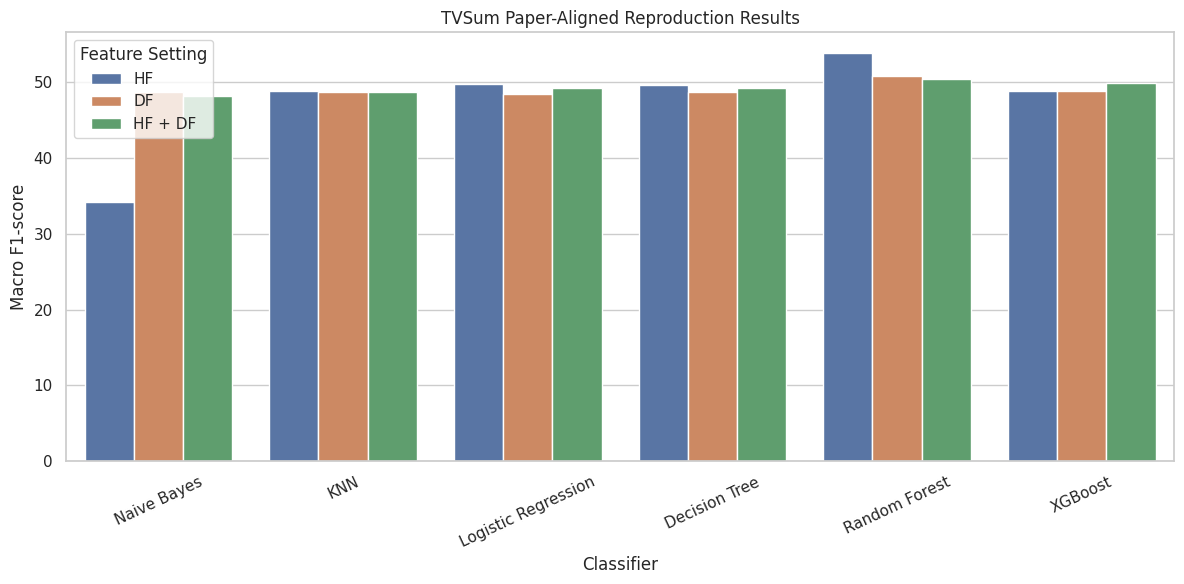

In [20]:
# ============================================================
# 20. OPTIONAL: VISUALIZE YOUR RESULTS
# ============================================================

plot_df = results_table.melt(
    id_vars="Classifier",
    var_name="Feature Setting",
    value_name="Macro F1-score",
).dropna()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="Classifier",
    y="Macro F1-score",
    hue="Feature Setting",
)
plt.title("TVSum Paper-Aligned Reproduction Results")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()